‘날짜가 있는 표’에서 ‘예측 시점이 분명한 데이터’로 정리한다. 행이 없어서 빠진 시점과 행은 있지만 값이 NaN인 경우는 다르다. 정렬한다고 중복이나 누락이 해결되지 않는다. 연간 자료의 변동을 월별 계절성처럼 해석하지 않는다.

In [68]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

In [70]:
sunspots = sm.datasets.sunspots.load_pandas()
dta = sunspots.data

dta['SUNACTIVITY']

0       5.0
1      11.0
2      16.0
3      23.0
4      36.0
       ... 
304    40.4
305    29.8
306    15.2
307     7.5
308     2.9
Name: SUNACTIVITY, Length: 309, dtype: float64

In [ ]:
##
def load_yearly_series(frame: pd.DataFrame, year_col: str, value_col: str) -> pd.Series:
    frame_copy = frame.copy()
    
    #잘못된 연도, 중복된 연도 오류 처리

    if frame_copy[year_col].isnull().any():
        raise ValueError("연도 결측값 존재")

    years = pd.to_numeric(frame_copy[year_col],errors="raise")
    if years.isnull().any():
        raise ValueError("연도 결측값 존재")
    if np.isinf(years).any():
        raise ValueError("연도 무한대값 존재")
    if (years.mod(1) != 0).any():
        raise ValueError("잘못된 연도 존재")

    
    
    years = years.astype('int64')


    
    if years.duplicated().any():
        raise ValueError("연도 중복값 존재")
    
    

    original_missing = frame_copy[value_col].isna()
    values = pd.to_numeric(frame_copy[value_col], errors="raise")
    if (values.isna() & ~original_missing).any():
        raise ValueError("관측값 변환 중 새로운 결측값이 생겼습니다.")
    if np.isinf(values).any():
        raise ValueError("관측값 무한대값 존재")

    #NaN 보존 점검 함수로 전달, 무한대 변환 불가 문자열 오류 처리
    #인덱스는 PeriodIndelx
    result = pd.Series(
        values.to_numpy(),
        index=pd.PeriodIndex(years.to_numpy(), freq="Y"),
        name=value_col,
    )
    return result.sort_index()

load_yearly_series(dta, 'YEAR', 'SUNACTIVITY')


1700     5.0
1701    11.0
1702    16.0
1703    23.0
1704    36.0
        ... 
2004    40.4
2005    29.8
2006    15.2
2007     7.5
2008     2.9
Freq: Y-DEC, Name: SUNACTIVITY, Length: 309, dtype: float64

In [122]:
def summarize_series(series: pd.Series) -> dict:
    if len(series) == 0:
        raise ValueError("빈 값")
    #시작/끝·관측 행 수·결측값 수·누락 연도 목록·중복 여부. 숫자 요약을 내면 그 값이 어느 기간의 것인지 명시한다.
    #복사
    copy = series.copy()
    #시작 끝
    start = [copy.iloc[[0]].index[0],copy.iloc[0]]
    end = [copy.iloc[[-1]].index[0],copy.iloc[-1]]
    #관측 행 수 
    row = len(series)
    #결측값 수
    nan = copy.isnull().sum()
    #누락 연도 목록
    year_excluded = []
    y_start = copy.iloc[[0]].index[0]
    y_end = copy.iloc[[-1]].index[0]

    for i in range(y_start.year  , y_end.year  ):
        
        if i not in copy.index.year:
            year_excluded.append(i)

    #중복 여부
    duplicate = copy.index.duplicated().any()
    #숫자요약?
    valid = copy.dropna()
    if valid.empty:
        mean = None
        min_value = None
        max_value = None
    else:
        mean = valid.mean()
        min_value = [valid.idxmin(), valid.min()]
        max_value = [valid.idxmax(), valid.max()]
    result = {'시작':start, "끝": end, '관측 행 수' : row, '결측값 수': nan,'누락 연도':year_excluded ,"중복 유무": duplicate, 
              'mean':mean, 'max':max_value,'min':min_value}
    result["요약 기간"] = {
        "시작": y_start,
        "끝": y_end,
        "결측 처리": "결측값 제외",
        "유효 관측 수": len(valid),
    }
    #기본 데이터에서 관측값 결측·누락이 없음을 실제로 확인한다. 있으면 모델링을 멈추고 원인과 처리 정책부터 기록한다.
    return result
series = load_yearly_series(dta, 'YEAR', 'SUNACTIVITY')
summarize_series(series)

{'시작': [Period('1700', 'Y-DEC'), np.float64(5.0)],
 '끝': [Period('2008', 'Y-DEC'), np.float64(2.9)],
 '관측 행 수': 309,
 '결측값 수': np.int64(0),
 '누락 연도': [],
 '중복 유무': np.False_,
 'mean': np.float64(49.75210355987054),
 'max': [Period('1957', 'Y-DEC'), np.float64(190.2)],
 'min': [Period('1711', 'Y-DEC'), np.float64(0.0)],
 '요약 기간': {'시작': Period('1700', 'Y-DEC'),
  '끝': Period('2008', 'Y-DEC'),
  '결측 처리': '결측값 제외',
  '유효 관측 수': 309}}

In [179]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

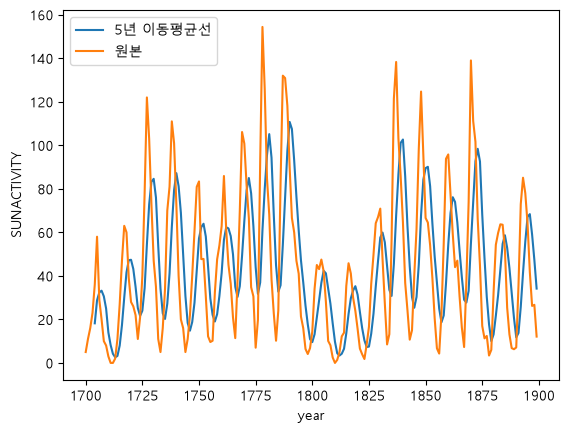

In [181]:
result = []

for j in range(1700, 1899+1):
    i = j-1700
    if i >= 4 :
        avg = (series.iloc[i]+series.iloc[i-1]+series.iloc[i-2]+series.iloc[i-3]+series.iloc[i-4])/5
        result.append(avg)


plt.figure()
plt.plot(series.index[4:200].year,result, label='5년 이동평균선')
plt.xlabel("year")
plt.ylabel("SUNACTIVITY")
plt.plot(series.index[:200].year, series.values[:200], label='원본')
plt.legend()
plt.show()